1. developper differents modeles de ML: pour cela il faut tester different modele et retenir celui qui a le meilleur performance.
2. Essayer d'ameliorer la performance: En optimisation ses hyperparametres.
3. compromis de Precision/Recall: enfin de trouver le meilleur threshold

In [3]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import seaborn as sbn 
from mpl_toolkits.mplot3d import axes3d
#% matplotlib inline

In [5]:
datasetcovid=pd.read_excel('dataset.xlsx')

In [7]:
pd.set_option('display.max_row',111)

In [9]:
#une nouvelle copie du dataset original
data_preproccessing=datasetcovid.copy()

In [11]:
# la 1ere de chose c'est de selectionner les variables qu'on a juge utiles dans le EDA
missing_rate=data_preproccessing.isna().sum(axis=0)/data_preproccessing.shape[0]
#creons la liste des variables les plus importantes
blood_columns2=list(data_preproccessing.columns[(missing_rate<0.9) & (missing_rate>0.88)])
viral_columns2=list(data_preproccessing.columns[(missing_rate<0.80) & (missing_rate>0.75)])
key_columns=['Patient age quantile','SARS-Cov-2 exam result']

In [13]:
data_preproccessing=data_preproccessing[key_columns + blood_columns2 + viral_columns2]

In [15]:
pd.set_option('display.max_column',data_preproccessing.shape[1])#permet d'afficher  colonne
data_preproccessing.head(5)

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
0,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected
2,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected


In [17]:
#import train_test_split depuis le module model selection.
from sklearn.model_selection import train_test_split
trainset,testset= train_test_split(data_preproccessing,test_size=0.2,random_state=45)
testset.head(3)

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
138,16,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
433,11,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1442,4,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
trainset.iloc[:,1].value_counts(),testset.iloc[:,1].value_counts()
#le proportion de chaque cas et bien respectee apres le decoupag

(SARS-Cov-2 exam result
 negative    4079
 positive     436
 Name: count, dtype: int64,
 SARS-Cov-2 exam result
 negative    1007
 positive     122
 Name: count, dtype: int64)

In [21]:
trainset.dropna().shape, testset.dropna().shape

((284, 33), (78, 33))

In [23]:
 #creons une fonction qui permet de faire l'encodage sur le train et le test
def encodage(data_preproccessing):
    #remplacons nos variables qualitalives par les varables quantitatives
    code={'positive':1,'negative':0,'detected':1,'not_detected':0}
    for col in data_preproccessing.select_dtypes('object'):
        data_preproccessing[col]=data_preproccessing[col].map(code)
    return data_preproccessing

In [25]:
encodage(trainset).dtypes.value_counts()

float64    31
int64       2
Name: count, dtype: int64

In [27]:
encodage(trainset)['Coronavirus229E'].value_counts()

Coronavirus229E
0.0    1078
1.0       5
Name: count, dtype: int64

In [33]:
def feature_engineering(dataframe):
    dataframe['est malade'] = dataframe[viral_columns2].sum(axis=1)>=1
    #eluminons toute les autres varables virarl
    dataframe=dataframe[key_columns + blood_columns2 + ['est malade']]

    return dataframe

In [37]:
# imputation
def imputation(dataframe):
    dataframe=encodage(dataframe)
    return dataframe.dropna(axis=0)

In [39]:
imputation(trainset).dtypes.value_counts()

float64    31
int64       2
Name: count, dtype: int64

In [41]:
def preprocessing(dataframe):
    dataframe=encodage(dataframe)
    #dataframe=feature_engineering(dataframe)
    dataframe=imputation(dataframe)
    print(dataframe.dtypes.value_counts(),type(dataframe))
    x=dataframe.drop(columns='SARS-Cov-2 exam result')
    y=dataframe['SARS-Cov-2 exam result']
    print('la proportion cas apres le preprocessing est de: {} {}'.format(x.shape,y.shape),sep="/n")
    return x,y
x_train,y_train=preprocessing(trainset)

float64    31
int64       2
Name: count, dtype: int64 <class 'pandas.core.frame.DataFrame'>
la proportion cas apres le preprocessing est de: (284, 32) (284,)


In [43]:
x_test,y_test=preprocessing(trainset)

float64    31
int64       2
Name: count, dtype: int64 <class 'pandas.core.frame.DataFrame'>
la proportion cas apres le preprocessing est de: (284, 32) (284,)


In [45]:
x_train.select_dtypes('int64')

,Patient age quantile
4484,4
5329,17
3432,4
4941,14
482,4
...,...
232,14
5230,13
196,18
4111,10


# Modelisation
   ### importons les defferents modeles de ML

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.svm import SVC #svm est tres efficace pour le dataset petit ou intermediare 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix,classification_report
from sklearn.model_selection import learning_curve#permet de voir si notre modele est en over ou endre fitting
from sklearn.feature_selection import SelectKBest,f_classif #c'est le test d'anova
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDClassifier

In [50]:
preprocessor=make_pipeline(PolynomialFeatures(2,include_bias=False))
#include_bias=False-permet d'enlever le colonne de biais 

In [52]:
# un liste de nos differents modeles sous forme d'un pipeline
DecisionTreeClassifier=make_pipeline(preprocessor,
                                     DecisionTreeClassifier(random_state=0))
RandomForestClassifier=make_pipeline(preprocessor,
                                     RandomForestClassifier(random_state=0))
AdaBoostClassifier=make_pipeline(preprocessor,
                                     AdaBoostClassifier(random_state=0))

#normalisons nos donnes avant d'utiliser un modele de kn_NEIGHBORS
from sklearn.preprocessing import MinMaxScaler,RobustScaler,StandardScaler
liste=[MinMaxScaler(),StandardScaler(),RobustScaler()]
KNeighborsClassifier=make_pipeline(preprocessor,liste[1],
                                     KNeighborsClassifier())
SVC=make_pipeline(preprocessor,liste[1],
                  SVC())
#les modeles bases sur les arbre de decision n'ont pas besoin des donnees normaliser

In [54]:
#Une liste de different modele de machine Learning
List_of_models={'DecisionTreeClassifier':DecisionTreeClassifier,
                'RandomForestClassifier':RandomForestClassifier,
               'AdaBoostClassifier':AdaBoostClassifier,
                'SVC':SVC,
                'KNeighborsClassifier':KNeighborsClassifier}

In [56]:
def evaluation(model):
    model.fit(x_train,y_train)
    score=model.score(x_train,y_train)
    y_prediction=model.predict(x_test)
    matrice_de_confusion=confusion_matrix(y_test,y_prediction)
    report=classification_report(y_test,y_prediction)
    print('la matrice de confusion \n {}'.format(matrice_de_confusion))
    print('{}'.format(report))
    
    #Essayons d'ameliorer le modele en tracant la courbe de validation enfin de bien comprendre notre modele.
    N,train_score,test_score=learning_curve(model,
                                            x_train,y_train,
                                           cv=4, scoring='f1',train_sizes=np.linspace(0.1,1,10))
    #tracons ls courbes
    plt.figure()
    
    plt.plot(N, train_score.mean(axis=1),color='b',label='le score sur le train')
    plt.plot(N, test_score.mean(axis=1),color='red',label='le score sur la validation ')
    #plt.title(nom_model)
    plt.legend()

le resultat du modele DecisionTreeClassifier:
la matrice de confusion 
 [[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284

le resultat du modele RandomForestClassifier:
la matrice de confusion 
 [[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284

le resultat du modele AdaBoostClassifier:


C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


la matrice de confusion 
 [[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\an

le resultat du modele SVC:
la matrice de confusion 
 [[242   0]
 [ 26  16]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       242
           1       1.00      0.38      0.55        42

    accuracy                           0.91       284
   macro avg       0.95      0.69      0.75       284
weighted avg       0.92      0.91      0.89       284

le resultat du modele KNeighborsClassifier:
la matrice de confusion 
 [[233   9]
 [ 16  26]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       242
           1       0.74      0.62      0.68        42

    accuracy                           0.91       284
   macro avg       0.84      0.79      0.81       284
weighted avg       0.91      0.91      0.91       284



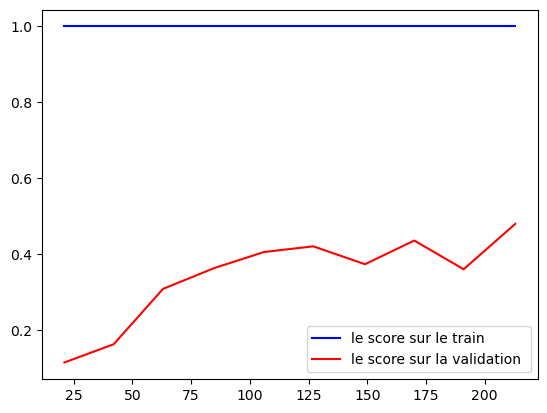

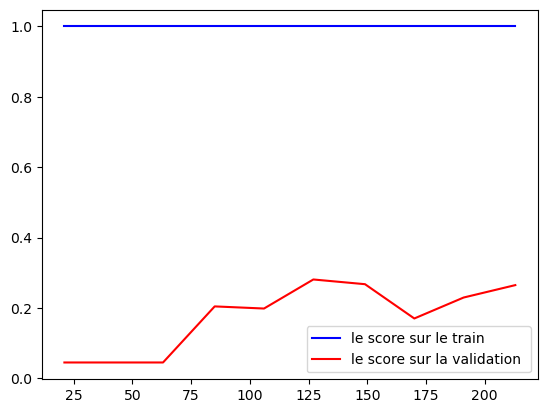

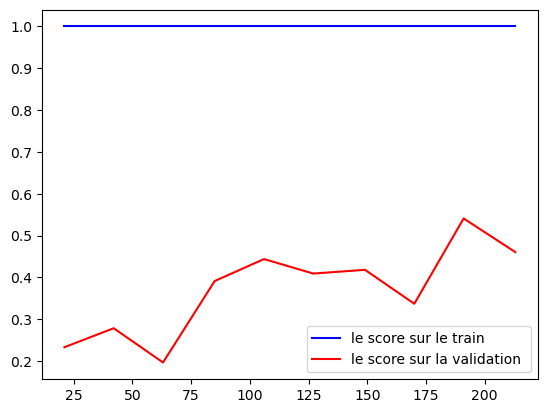

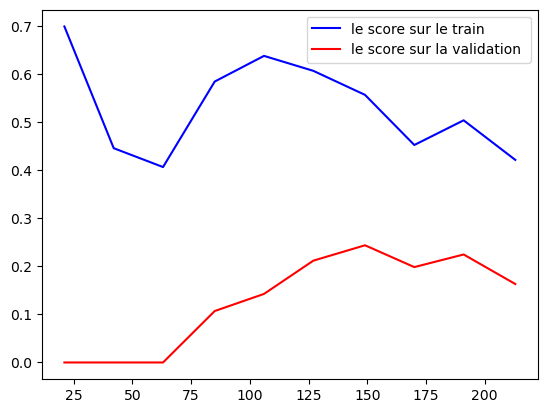

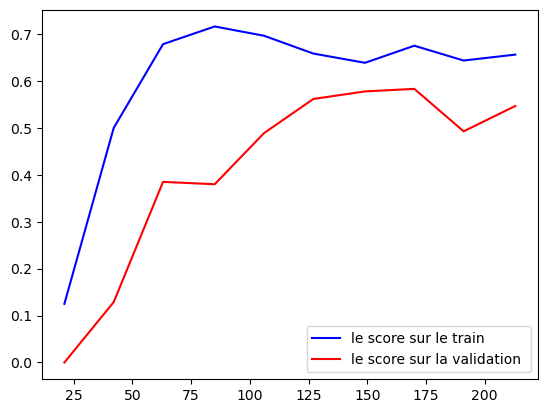

In [58]:
for modele,value in List_of_models.items():
    print('le resultat du modele {}:'.format(modele))
    evaluation(value)

D'après les graphiques, on constate que le premier modèle souffre d'overfitting, car il ne parvient pas à généraliser. Le troisième modèle est meilleur que les deux précédents, car son score de validation augmente plus rapidement. Pour les deux derniers modèles, bien que le score d'entraînement diminue, on observe une convergence entre les scores d'entraînement et de validation, ce qui est un très bon signe, car cela indique une meilleure généralisation du modèle.

### Optimisation d'un modele.
c.a.d essayer de trouver les meilleurs hyperparametre. dans notre cas SVM

In [62]:
#permet de voir les differents parametre du model 
SVC.get_params()

{'memory': None,
 'steps': [('pipeline',
   Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False))])),
  ('standardscaler', StandardScaler()),
  ('svc', SVC())],
 'verbose': False,
 'pipeline': Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False))]),
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'pipeline__memory': None,
 'pipeline__steps': [('polynomialfeatures',
   PolynomialFeatures(include_bias=False))],
 'pipeline__verbose': False,
 'pipeline__polynomialfeatures': PolynomialFeatures(include_bias=False),
 'pipeline__polynomialfeatures__degree': 2,
 'pipeline__polynomialfeatures__include_bias': False,
 'pipeline__polynomialfeatures__interaction_only': False,
 'pipeline__polynomialfeatures__order': 'C',
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__deci

In [66]:
# importons grigsearcheCV
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
"""
gridparams={'svc__gamma': [1e-3,1e-4,1e-2],
    'svc__C':[1,10,100,1000]       
}
"""
RandomizedSearchCV_params={'svc__gamma': [1e-3,1e-4,1e-2],
                           'svc__C':[1,10,100,1000],
                           'pipeline__polynomialfeatures__degree':[2,3,4]#,'pipeline__selectkbest__k':np.arange(40,60)  
                          }
#grid=GridSearchCV(SVC,gridparams,scoring='recall',cv=4)
Randomgrid=RandomizedSearchCV(SVC,RandomizedSearchCV_params,scoring='recall',cv=4,n_iter=20)
#n_iter c'est le nombre diteration cad le nombre de combunaison differente enfin de trouver les meilleurs hyperparametre
Randomgrid.fit(x_train,y_train)

RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('pipeline',
                                              Pipeline(steps=[('polynomialfeatures',
                                                               PolynomialFeatures(include_bias=False))])),
                                             ('standardscaler',
                                              StandardScaler()),
                                             ('svc', SVC())]),
                   n_iter=20,
                   param_distributions={'pipeline__polynomialfeatures__degree': [2,
                                                                                 3,
                                                                                 4],
                                        'svc__C': [1, 10, 100, 1000],
                                        'svc__gamma': [0.001, 0.0001, 0.01]},
                   scoring='recall')

In [67]:
Randomgrid.best_params_

{'svc__gamma': 0.0001,
 'svc__C': 1000,
 'pipeline__polynomialfeatures__degree': 2}

In [68]:
Randomgrid.best_score_

0.7090909090909091

In [72]:
meilleur_stimateur=Randomgrid.best_estimator_ #le meilleur stimateur

In [74]:
y_pred=meilleur_stimateur.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[241   1]
 [  2  40]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       242
           1       0.98      0.95      0.96        42

    accuracy                           0.99       284
   macro avg       0.98      0.97      0.98       284
weighted avg       0.99      0.99      0.99       284



la matrice de confusion 
 [[241   1]
 [  2  40]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       242
           1       0.98      0.95      0.96        42

    accuracy                           0.99       284
   macro avg       0.98      0.97      0.98       284
weighted avg       0.99      0.99      0.99       284



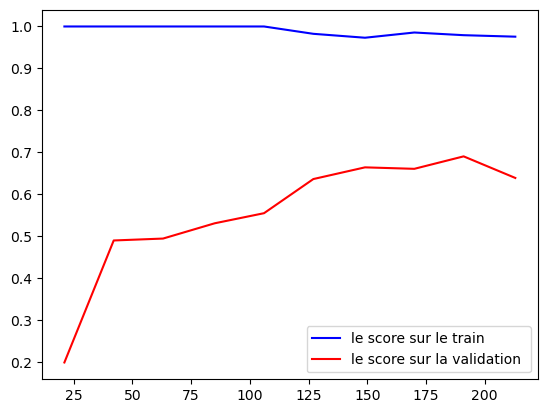

In [76]:
evaluation(meilleur_stimateur)

On peut encore essayer d'optimiser tous les hyperparamètres pour obtenir de meilleurs résultats avec GridSearchCV. Cependant, effectuer une recherche exhaustive avec GridSearchCV peut être très coûteux en termes de temps. Pour pallier ce problème, une alternative efficace est d'utiliser RandomizedSearchCV, qui explore de manière aléatoire différentes combinaisons au sein de l'ensemble des hyperparamètres. Cela permet de réduire le temps de calcul tout en maintenant une bonne chance de trouver des configurations performantes

## Precision Recall curve.
finalisons la creation du modele en observant les courbe precisions/recalls et en definisant un seil de prediction(decision banderie pour notre modele.

In [82]:
from sklearn.metrics import precision_recall_curve
prediction,recall,threshold=precision_recall_curve(y_test,meilleur_stimateur.decision_function(x_test))

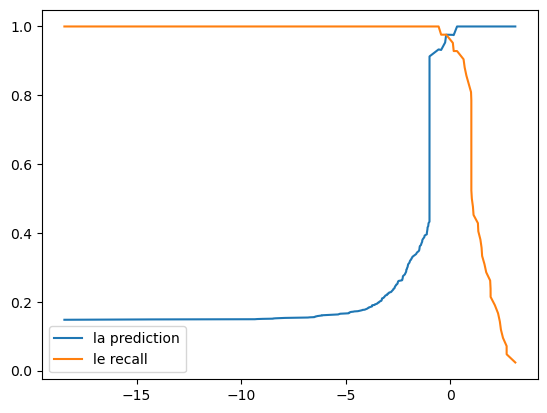

In [84]:
#affichons le trois tableaux 
plt.plot(threshold,prediction[:-1],label='la prediction')
plt.plot(threshold,recall[:-1],label='le recall')
plt.legend()

selon le graphique de precision_recall_curve , lorsque le theshold est entre -1 et 1, la precision et le recall ont le meileur score. choisissons pour notre modele un seil dans cet interva

## Evlautaion final

In [90]:
def model_final(modele,x,threshold):
    return modele.decision_function(x) >threshold

In [92]:
nouveau_y_pred=model_final(meilleur_stimateur,x_test,threshold=-0.85)
#evalution avec le score f1
from sklearn.metrics import precision_score,f1_score,recall_score
print('on a un score f1 de: {}' .format(f1_score(y_test,nouveau_y_pred)))
print('on a un recall de: {}' .format(recall_score(y_test,nouveau_y_pred)))

on a un score f1 de: 0.9655172413793104
on a un recall de: 1.0


# ccl: 
On a au final un modele avec une score f1 de 0.96 et un recall de 1.0